# Phase 4 — Manipulator sampling-time sweep (our Phase-1.3 controller)

Example-2 counterpart of `dubins_sweep.ipynb`, same test design:

- **Fixed physical horizon** `T_hor = dt x N = 0.20 s`; dt divides it exactly
  so `N = T_hor/dt` is integer.
- **success = REACHED** (`phi <= phi_tol`); first-step infeasibility = failure.
- Safety margin is a reported **diagnostic**, not a gate.
- Per-config **cache** (skip already-computed (method, dt); `REGENERATE=True`
  forces recompute); raw CSV checkpointed each config.

|  dt (s)   |   N    |      T_hor (s)      |
| :-------: | :----: | :-----------------: |
|   0.005   |   40   |        0.20         |
| **0.010** | **20** | **0.20** (baseline) |
|   0.020   |   10   |        0.20         |
|   0.040   |   5    |        0.20         |

**Ours-specific:** acrobot dynamics; RA-MPC terminal set =
`manipulator_constrained.py` certificate; per-channel bounds
`u_max_eff=(tau1, tau2)` from Phase 1.3. Candidates sampled in output space
via inverse kinematics. Needs casadi + joblib + scipy + sympy (env `rab_mpc`).


## §1 — Load our controller + bounds; acrobot constants; sets


In [ ]:
import sys, os, time, json, importlib.util
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import casadi as ca
import pandas as pd
from scipy.integrate import solve_ivp
from joblib import Parallel, delayed

ROOT = os.path.abspath(os.getcwd())
for _ in range(6):
    if os.path.isdir(os.path.join(ROOT, "revision", "matlab_frozen")):
        break
    ROOT = os.path.dirname(ROOT)
REV = os.path.join(ROOT, "revision")
CTRL = os.path.join(REV, "controllers")
REV_DATA = os.path.join(REV, "data")

# --- our Phase-1.3 RA controller (cert = RA-MPC terminal) + per-channel bounds
with open(os.path.join(REV_DATA, "phase1_3_meta_manipulator.json")) as fh:
    meta = json.load(fh)
U_MAX = [float(meta["u_max_eff"]["tau1"]), float(meta["u_max_eff"]["tau2"])]
u1_max, u2_max = U_MAX
CONST = json.load(open(os.path.join(REV_DATA, "phase1_2_outputs_manipulator.json")))[
    "system_constants"
]
m1, m2 = CONST["m1"], CONST["m2"]
l1, l2 = CONST["l1"], CONST["l2"]
lc1, lc2 = CONST["lc1"], CONST["lc2"]
I1, I2 = CONST["I1"], CONST["I2"]
g_grav = CONST["g"]

spec = importlib.util.spec_from_file_location(
    "manipulator_constrained", os.path.join(CTRL, "manipulator_constrained.py")
)
ra_mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(ra_mod)
cert = sp.sympify(ra_mod.certificate_opt)

# --- 4-D acrobot state + output sets (frozen example) ---------------------
x1, x2, x3, x4 = sp.symbols("x1 x2 x3 x4")
y1, y2 = sp.symbols("y1 y2")
state_vars = [x1, x2, x3, x4]
TARGET_POS = np.array([5.8, 1.9])  # target ellipse centre in y-space


def h_np(x_):
    q1, q2 = x_[0], x_[1]
    return np.array(
        [l1 * np.cos(q1) + l2 * np.cos(q1 + q2), l1 * np.sin(q1) + l2 * np.sin(q1 + q2)]
    )


def psi_y(y1v, y2v):  # safe: psi >= 0
    return -((4 * (y1v - 2) - 2 * y2v**3) ** 2) + 0.8 * y2v**3 + 10


def phi_y(y1v, y2v):  # target: phi <= 0
    return ((y1v - 2 - 3.5) ** 2 / 1.2**2) + ((y2v - 1.8) ** 2 / 0.4**2) - 2


def psi_x(x_):
    y = h_np(x_)
    return psi_y(y[0], y[1])


def phi_x(x_):
    y = h_np(x_)
    return phi_y(y[0], y[1])


def acrobot_rhs_np(t, x_, u_):
    q1, q2, dq1, dq2 = x_
    M11 = I1 + I2 + m1 * lc1**2 + m2 * (l1**2 + lc2**2 + 2 * l1 * lc2 * np.cos(q2))
    M12 = m2 * (lc2**2 + l1 * lc2 * np.cos(q2)) + I2
    M = np.array([[M11, M12], [M12, m2 * lc2**2 + I2]])
    C = np.array(
        [
            [
                -m2 * l1 * lc2 * np.sin(q2) * dq2,
                -m2 * l1 * lc2 * np.sin(q2) * (dq1 + dq2),
            ],
            [m2 * l1 * lc2 * np.sin(q2) * dq1, 0.0],
        ]
    )
    G = np.array(
        [
            (m1 * g_grav * lc1 + m2 * g_grav * l1) * np.cos(q1)
            + m2 * g_grav * lc2 * np.cos(q1 + q2),
            m2 * g_grav * lc2 * np.cos(q1 + q2),
        ]
    )
    qddot = np.linalg.solve(M, -C @ np.array([dq1, dq2]) - G + np.asarray(u_))
    return [dq1, dq2, qddot[0], qddot[1]]


def inverse_kinematics(y1v, y2v, L1, L2):
    """2-link IK; returns (elbow-down, elbow-up) (q1,q2) solutions."""
    r2 = y1v**2 + y2v**2
    cq2 = (r2 - L1**2 - L2**2) / (2 * L1 * L2)
    q2a = np.arccos(cq2)
    q2b = -np.arccos(cq2)
    phi = np.arctan2(y2v, y1v)
    q1a = phi - np.arctan2(L2 * np.sin(q2a), L1 + L2 * np.cos(q2a))
    q1b = phi - np.arctan2(L2 * np.sin(q2b), L1 + L2 * np.cos(q2b))
    return (q1a, q2a), (q1b, q2b)


print("RA terminal = our manipulator_constrained.py cert | u_max_eff =", U_MAX)

RA terminal = our manipulator_constrained.py cert | u_max_eff = [679.2, 500.1]


## §2 — CasADi: certificate / safe set / acrobot RK4 factory


In [ ]:
def sympy2casadi(expr, sym_map):
    if isinstance(
        expr,
        (
            sp.Integer,
            sp.Float,
            sp.Rational,
            sp.core.numbers.NegativeOne,
            sp.core.numbers.Half,
            sp.core.numbers.One,
            sp.core.numbers.Zero,
            sp.core.numbers.Pi,
        ),
    ):
        return float(expr)
    if isinstance(expr, sp.Symbol):
        return sym_map[expr]
    if isinstance(expr, sp.Add):
        return sum(sympy2casadi(a, sym_map) for a in expr.args)
    if isinstance(expr, sp.Mul):
        r = 1.0
        for a in expr.args:
            r = r * sympy2casadi(a, sym_map)
        return r
    if isinstance(expr, sp.Pow):
        return sympy2casadi(expr.args[0], sym_map) ** sympy2casadi(
            expr.args[1], sym_map
        )
    if isinstance(expr, sp.sin):
        return ca.sin(sympy2casadi(expr.args[0], sym_map))
    if isinstance(expr, sp.cos):
        return ca.cos(sympy2casadi(expr.args[0], sym_map))
    if isinstance(expr, sp.Number):
        return float(expr)
    raise ValueError(f"Unsupported sympy type: {type(expr)}")


ca_x1 = ca.SX.sym("x1")
ca_x2 = ca.SX.sym("x2")
ca_x3 = ca.SX.sym("x3")
ca_x4 = ca.SX.sym("x4")
sym_map = {x1: ca_x1, x2: ca_x2, x3: ca_x3, x4: ca_x4}
cert_ca_f = ca.Function(
    "cert", [ca_x1, ca_x2, ca_x3, ca_x4], [sympy2casadi(cert, sym_map)]
)


def cert_vec(xv):
    return cert_ca_f(xv[0], xv[1], xv[2], xv[3])


def safe_vec(xv):  # psi(h(x)) >= 0 in CasADi
    y1v = l1 * ca.cos(xv[0]) + l2 * ca.cos(xv[0] + xv[1])
    y2v = l1 * ca.sin(xv[0]) + l2 * ca.sin(xv[0] + xv[1])
    return -((4 * (y1v - 2) - 2 * y2v**3) ** 2) + 0.8 * y2v**3 + 10


def target_vec(xv):  # phi(h(x)) <= 0
    y1v = l1 * ca.cos(xv[0]) + l2 * ca.cos(xv[0] + xv[1])
    y2v = l1 * ca.sin(xv[0]) + l2 * ca.sin(xv[0] + xv[1])
    return ((y1v - 2 - 3.5) ** 2 / 1.2**2) + ((y2v - 1.8) ** 2 / 0.4**2) - 2


def h_ca(xv):
    return ca.vertcat(
        l1 * ca.cos(xv[0]) + l2 * ca.cos(xv[0] + xv[1]),
        l1 * ca.sin(xv[0]) + l2 * ca.sin(xv[0] + xv[1]),
    )


xc_g = ca.MX.sym("x", 4)
uc_g = ca.MX.sym("u", 2)


def acrobot_ca(x, u):
    q1, q2, dq1, dq2 = x[0], x[1], x[2], x[3]
    M11 = I1 + I2 + m1 * lc1**2 + m2 * (l1**2 + lc2**2 + 2 * l1 * lc2 * ca.cos(q2))
    M12 = m2 * (lc2**2 + l1 * lc2 * ca.cos(q2)) + I2
    M = ca.vertcat(ca.horzcat(M11, M12), ca.horzcat(M12, m2 * lc2**2 + I2))
    C = ca.vertcat(
        ca.horzcat(
            -m2 * l1 * lc2 * ca.sin(q2) * dq2, -m2 * l1 * lc2 * ca.sin(q2) * (dq1 + dq2)
        ),
        ca.horzcat(m2 * l1 * lc2 * ca.sin(q2) * dq1, ca.DM(0.0)),
    )
    G = ca.vertcat(
        (m1 * g_grav * lc1 + m2 * g_grav * l1) * ca.cos(q1)
        + m2 * g_grav * lc2 * ca.cos(q1 + q2),
        m2 * g_grav * lc2 * ca.cos(q1 + q2),
    )
    qddot = ca.solve(M, -C @ ca.vertcat(dq1, dq2) - G + u)
    return ca.vertcat(dq1, dq2, qddot[0], qddot[1])


rhs_ca_g = ca.Function("f", [xc_g, uc_g], [acrobot_ca(xc_g, uc_g)])


def make_F_disc(dt):
    k1 = rhs_ca_g(xc_g, uc_g)
    k2 = rhs_ca_g(xc_g + dt / 2 * k1, uc_g)
    k3 = rhs_ca_g(xc_g + dt / 2 * k2, uc_g)
    k4 = rhs_ca_g(xc_g + dt * k3, uc_g)
    return ca.Function(
        "F_disc", [xc_g, uc_g], [xc_g + (dt / 6) * (k1 + 2 * k2 + 2 * k3 + k4)]
    )


# sanity: sympy vs casadi certificate
test_x = np.array([-1.0, 2.0, 0.1, -0.1])
assert (
    abs(float(cert.subs(dict(zip(state_vars, test_x)))) - float(cert_ca_f(*test_x)))
    < 1e-3
)
print("CasADi functions built; certificate conversion verified.")

CasADi functions built; certificate conversion verified.


## §3 — Sweep config (fixed T_hor = 0.20 s) + candidate set (IK)


In [ ]:
T_HOR_FIXED = 0.20
N_CANDIDATES = 150  # acrobot MPC is heavier; matches main-notebook cap
T_max = 10.0
phi_tol = 0.05
_IPOPT_OPTS = {
    "ipopt.print_level": 0,
    "print_time": 0,
    "ipopt.max_iter": 500,
    "ipopt.tol": 1e-4,
    "ipopt.acceptable_tol": 1e-3,
}
DT_N_PAIRS = [(0.005, 40), (0.010, 20), (0.020, 10), (0.040, 5)]
CONFIGS = [
    {"dt_mpc": dt, "N_hor": N, "T_hor_actual": round(N * dt, 4)} for dt, N in DT_N_PAIRS
]
for c in CONFIGS:
    assert abs(c["T_hor_actual"] - T_HOR_FIXED) < 1e-9
print(
    f"T_hor = {T_HOR_FIXED}s fixed | success = REACHED / {N_CANDIDATES} | u_max_eff = {U_MAX}"
)

# candidates: sample output space, IK (elbow-down, qdot=0), keep safe & outside target
np.random.seed(42)
N_pool = 2000
y1s = np.random.uniform(-1.0, 5.5, N_pool)
y2s = np.random.uniform(-4.0, 3.1, N_pool)
xl = []
for i in range(N_pool):
    r2 = y1s[i] ** 2 + y2s[i] ** 2
    if r2 > (l1 + l2) ** 2 or r2 < 1e-4:
        xl.append([np.nan] * 4)
        continue
    (q1, q2), _ = inverse_kinematics(y1s[i], y2s[i], l1, l2)  # elbow-down branch
    xl.append(
        [q1, q2, 0.0, 0.0] if (np.isfinite(q1) and np.isfinite(q2)) else [np.nan] * 4
    )
X = np.array(xl).T
valid = np.all(np.isfinite(X), axis=0)
psi_v = np.where(
    valid,
    np.array([psi_x(X[:, i]) if valid[i] else -np.inf for i in range(N_pool)]),
    -np.inf,
)
phi_v = np.where(
    valid,
    np.array([phi_x(X[:, i]) if valid[i] else -np.inf for i in range(N_pool)]),
    -np.inf,
)
cand_idx = np.where((psi_v >= 0) & (phi_v > 0))[0][:N_CANDIDATES]
x_cands = X[:, cand_idx]
print(f"{x_cands.shape[1]} candidates selected (safe & outside target, seed=42).")

T_hor = 0.2s fixed | success = REACHED / 150 | u_max_eff = [679.2, 500.1]
150 candidates selected (safe & outside target, seed=42).


## §4 — MPC solver factory + closed-loop simulation


In [ ]:
def make_solver(dt, N, method):
    """method = 'vanilla' (target terminal) or 'ra' (our certificate terminal)."""
    F = make_F_disc(dt)

    def solve(x0_val, U_warm=None):
        opti = ca.Opti()
        X = opti.variable(4, N + 1)
        U_var = opti.variable(2, N)
        x0 = np.asarray(x0_val, float).flatten()
        opti.subject_to(X[:, 0] == x0)
        for k in range(N):
            opti.subject_to(X[:, k + 1] == F(X[:, k], U_var[:, k]))
            opti.subject_to(safe_vec(X[:, k]) >= 0)
        opti.subject_to(safe_vec(X[:, N]) >= 0)
        if method == "vanilla":
            opti.subject_to(target_vec(X[:, N]) <= 0)
        else:
            opti.subject_to(cert_vec(X[:, N]) >= 0)
        opti.subject_to(opti.bounded(-u1_max, U_var[0, :], u1_max))
        opti.subject_to(opti.bounded(-u2_max, U_var[1, :], u2_max))
        tgt = ca.DM(TARGET_POS)
        Q = ca.DM([[5.0, 0], [0, 5.0]])
        Qf = ca.DM([[80.0, 0], [0, 80.0]])
        R = ca.DM([[1e-3, 0], [0, 1e-3]])
        cost = 0
        for k in range(N):
            dy = h_ca(X[:, k]) - tgt
            cost += dy.T @ Q @ dy + U_var[:, k].T @ R @ U_var[:, k]
        cost += (h_ca(X[:, N]) - tgt).T @ Qf @ (h_ca(X[:, N]) - tgt)
        opti.minimize(cost)
        if U_warm is not None:
            U_ws = np.hstack([U_warm[:, 1:], U_warm[:, -1:]])
            X_ws = np.zeros((4, N + 1))
            X_ws[:, 0] = x0
            for k in range(N):
                X_ws[:, k + 1] = np.asarray(F(X_ws[:, k], U_ws[:, k])).flatten()
            opti.set_initial(X, X_ws)
            opti.set_initial(U_var, U_ws)
        else:
            xtf = np.array([np.arctan2(TARGET_POS[1], TARGET_POS[0]), 0.0, 0.0, 0.0])
            X_ws = np.array([(1 - k / N) * x0 + (k / N) * xtf for k in range(N + 1)]).T
            opti.set_initial(X, X_ws)
            opti.set_initial(U_var, 0)
        opti.solver("ipopt", _IPOPT_OPTS)
        t0 = time.perf_counter()
        try:
            sol = opti.solve()
            return (
                True,
                np.asarray(sol.value(U_var)).reshape(2, N),
                (time.perf_counter() - t0) * 1e3,
            )
        except Exception:
            return False, None, (time.perf_counter() - t0) * 1e3

    return solve


def simulate_one(x0, solve_fn, dt):
    x = np.asarray(x0, float).copy()
    xs = [x.copy()]
    ts = [0.0]
    t = 0.0
    U_prev = None
    step_ms = []
    n_inf = 0
    eff = 0.0
    while t < T_max - 1e-9:
        if float(phi_x(x)) <= 0:
            break
        ok, U_opt, ms = solve_fn(x, U_warm=U_prev)
        step_ms.append(ms)
        if not ok:
            n_inf += 1
            break
        u0 = np.array(U_opt[:, 0]).flatten()
        U_prev = U_opt
        sol = solve_ivp(
            lambda _t, xx: acrobot_rhs_np(_t, xx, u0),
            [t, t + dt],
            x,
            method="DOP853",
            rtol=1e-8,
            atol=1e-10,
            max_step=dt / 10,
        )
        if not np.all(np.isfinite(sol.y)):
            break
        x = sol.y[:, -1]
        t += dt
        xs.append(x.copy())
        ts.append(t)
        eff += (u0[0] ** 2 + u0[1] ** 2) * dt
    ts = np.array(ts)
    xs = np.array(xs)
    phi_f = float(phi_x(xs[-1]))
    success = phi_f <= phi_tol
    n_steps = len(ts) - 1
    stms = np.array(step_ms) if step_ms else np.array([0.0])
    if success:
        outcome = "REACHED"
    elif n_inf > 0 and n_steps == 0:
        outcome = "INFEASIBLE_STEP1"
    elif n_inf > 0 and n_steps > 0:
        outcome = "INFEASIBLE_MID"
    elif t >= T_max - 1e-9:
        outcome = "TIMEOUT"
    else:
        outcome = "DIVERGED"
    min_margin = float(np.min([psi_x(xs[k]) for k in range(len(xs))]))
    return {
        "success": success,
        "outcome": outcome,
        "time_to_target": float(ts[-1]) if success else float("nan"),
        "sim_duration": float(ts[-1]),
        "control_effort": eff,
        "min_safety_margin": min_margin,
        "n_infeasible": n_inf,
        "n_steps": n_steps,
        "mean_step_ms": float(stms.mean()),
        "total_solve_ms": float(stms.sum()),
    }


def _run(i, dt, N, method_key):
    return simulate_one(x_cands[:, i], make_solver(dt, N, method_key), dt)


print("Simulation functions ready.")

Simulation functions ready.


## §5 — Run the sweep (per-config cache; threads)


In [ ]:
REGENERATE = False
RAW_PATH = os.path.join(REV_DATA, "manipulator_sweep_raw.csv")
SEED = 42
SIG = {
    "N_CANDIDATES": N_CANDIDATES,
    "seed": SEED,
    "u1_max": round(u1_max, 6),
    "u2_max": round(u2_max, 6),
}


def _sig_ok(row):
    return (
        int(row["N_CANDIDATES"]) == SIG["N_CANDIDATES"]
        and int(row["seed"]) == SIG["seed"]
        and abs(float(row["u1_max"]) - SIG["u1_max"]) < 1e-6
        and abs(float(row["u2_max"]) - SIG["u2_max"]) < 1e-6
    )


cached = pd.DataFrame()
if (not REGENERATE) and os.path.exists(RAW_PATH):
    prev = pd.read_csv(RAW_PATH)
    if all(c in prev.columns for c in SIG):
        cached = prev[prev.apply(_sig_ok, axis=1)].copy()
    print(f"cache: {len(cached)} matching rows in {os.path.basename(RAW_PATH)}")

done_keys = set(zip(cached["method"], cached["dt_mpc"])) if len(cached) else set()
all_rows = cached.to_dict("records") if len(cached) else []

for cfg in CONFIGS:
    dt, N, T_h = cfg["dt_mpc"], cfg["N_hor"], cfg["T_hor_actual"]
    for method_name, method_key in [
        ("Vanilla MPC", "vanilla"),
        ("RA-MPC (ours)", "ra"),
    ]:
        if (method_name, dt) in done_keys:
            print(f"--- dt={dt:.3f}s [{method_name}] CACHED -> skip ---", flush=True)
            continue
        print(
            f"--- dt={dt:.3f}s N={N} T_hor={T_h:.3f}s [{method_name}] ---", flush=True
        )
        tw = time.perf_counter()
        results = Parallel(n_jobs=-1, prefer="threads")(
            delayed(_run)(i, dt, N, method_key) for i in range(N_CANDIDATES)
        )
        wall = time.perf_counter() - tw
        oc = {}
        for r in results:
            oc[r["outcome"]] = oc.get(r["outcome"], 0) + 1
        nr = oc.get("REACHED", 0)
        print(
            f"  {wall:.1f}s wall | REACHED={nr} INF_S1={oc.get('INFEASIBLE_STEP1',0)} "
            f"INF_MID={oc.get('INFEASIBLE_MID',0)} TIMEOUT={oc.get('TIMEOUT',0)} "
            f"DIVERGED={oc.get('DIVERGED',0)} | rate={100*nr/N_CANDIDATES:.1f}%",
            flush=True,
        )
        for i, r in enumerate(results):
            r.update(
                {
                    "dt_mpc": dt,
                    "N_hor": N,
                    "T_hor_actual": T_h,
                    "method": method_name,
                    "cand_id": i,
                    **SIG,
                }
            )
        all_rows.extend(results)
        pd.DataFrame(all_rows).to_csv(RAW_PATH, index=False)

df = pd.DataFrame(all_rows)
print(
    f"\nSweep complete. rows: {len(df)}  (raw CSV checkpointed at {os.path.basename(RAW_PATH)})"
)

cache: 1200 matching rows in manipulator_sweep_raw.csv
--- dt=0.005s [Vanilla MPC] CACHED -> skip ---
--- dt=0.005s [RA-MPC (ours)] CACHED -> skip ---
--- dt=0.010s [Vanilla MPC] CACHED -> skip ---
--- dt=0.010s [RA-MPC (ours)] CACHED -> skip ---
--- dt=0.020s [Vanilla MPC] CACHED -> skip ---
--- dt=0.020s [RA-MPC (ours)] CACHED -> skip ---
--- dt=0.040s [Vanilla MPC] CACHED -> skip ---
--- dt=0.040s [RA-MPC (ours)] CACHED -> skip ---

Sweep complete. rows: 1200  (raw CSV checkpointed at manipulator_sweep_raw.csv)


## §6 — Summary table + save


In [ ]:
summary = (
    df.groupby(["method", "dt_mpc", "N_hor"])
    .agg(
        n_reached=("success", "sum"),
        n_infeas_s1=("outcome", lambda x: (x == "INFEASIBLE_STEP1").sum()),
        n_infeas_mid=("outcome", lambda x: (x == "INFEASIBLE_MID").sum()),
        n_timeout=("outcome", lambda x: (x == "TIMEOUT").sum()),
        mean_ttt=("time_to_target", lambda x: round(np.nanmean(x), 3)),
        worst_safety_margin=("min_safety_margin", lambda x: round(x.min(), 4)),
    )
    .reset_index()
)
summary["success_rate"] = (summary["n_reached"] / N_CANDIDATES * 100).round(1)
cols = [
    "method",
    "dt_mpc",
    "N_hor",
    "n_reached",
    "success_rate",
    "n_infeas_s1",
    "n_infeas_mid",
    "n_timeout",
    "mean_ttt",
    "worst_safety_margin",
]
print("=== Sweep summary (rates out of %d) ===" % N_CANDIDATES)
print(summary[cols].sort_values(["method", "dt_mpc"]).to_string(index=False))
print("\n=== success_rate (%) pivot ===")
print(
    summary.pivot(index="dt_mpc", columns="method", values="success_rate").to_string()
)
summary.to_csv(os.path.join(REV_DATA, "manipulator_sweep_summary.csv"), index=False)
print("\nsaved manipulator_sweep_summary.csv (raw checkpointed in §5)")

=== Sweep summary (rates out of 150) ===
       method  dt_mpc  N_hor  n_reached  success_rate  n_infeas_s1  n_infeas_mid  n_timeout  mean_ttt  worst_safety_margin
RA-MPC (ours)   0.005     40        115          76.7           35             0          0     0.523               0.0000
RA-MPC (ours)   0.010     20        120          80.0           30             0          0     0.456               0.0000
RA-MPC (ours)   0.020     10        106          70.7            6            38          0     0.372              -0.0000
RA-MPC (ours)   0.040      5         33          22.0            1           116          0     0.219              -0.0024
  Vanilla MPC   0.005     40        113          75.3           37             0          0     0.255               0.0000
  Vanilla MPC   0.010     20        113          75.3           37             0          0     0.247               0.0000
  Vanilla MPC   0.020     10        108          72.0           37             5          0     0.

## §7 — Plots (each its own figure; main-notebook style)


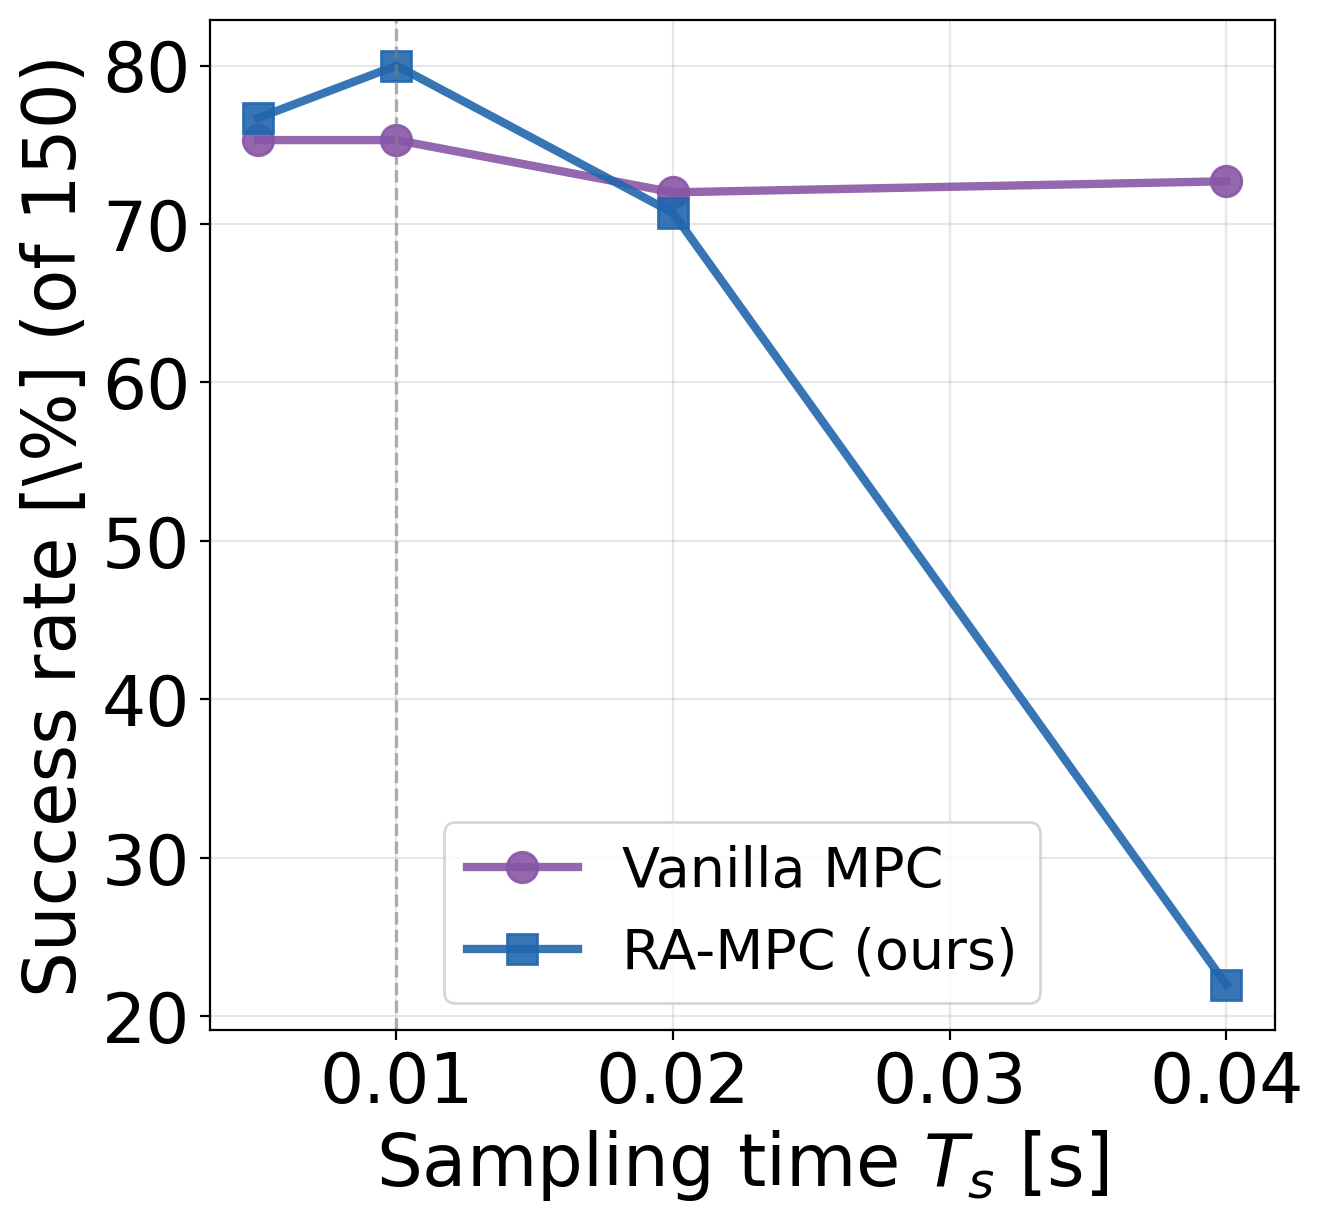

saved manipulator_sweep_success_rate.png


In [ ]:
# ── Plot 1: success rate vs sampling time ─────────────────────────────────────
methods = ["Vanilla MPC", "RA-MPC (ours)"]
col_c = {"Vanilla MPC": "#8856a7", "RA-MPC (ours)": "#2166ac"}
mk = {"Vanilla MPC": "o", "RA-MPC (ours)": "s"}
fs = 30

px_fig = 1 / plt.rcParams["figure.dpi"]
fig, ax = plt.subplots(figsize=(650 * px_fig, 600 * px_fig), layout="constrained")
fig.set_dpi(200)
for m in methods:
    sub = summary[summary["method"] == m].sort_values("dt_mpc")
    ax.plot(
        sub["dt_mpc"],
        sub["success_rate"],
        color=col_c[m],
        marker=mk[m],
        lw=3,
        ms=11,
        alpha=0.9,
        label=m,
    )
ax.axvline(0.01, color="gray", lw=1.2, ls="--", alpha=0.6)
ax.set_xlabel("Sampling time $T_s$ [s]", fontsize=fs - 4)
ax.set_ylabel(f"Success rate [\\%] (of {N_CANDIDATES})", fontsize=fs - 4)
ax.xaxis.set_tick_params(labelsize=25)
ax.yaxis.set_tick_params(labelsize=25)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=20)
fig.savefig(
    os.path.join(REV_DATA, "manipulator_sweep_success_rate.png"),
    dpi=200,
    bbox_inches="tight",
)
plt.show()
print("saved manipulator_sweep_success_rate.png")

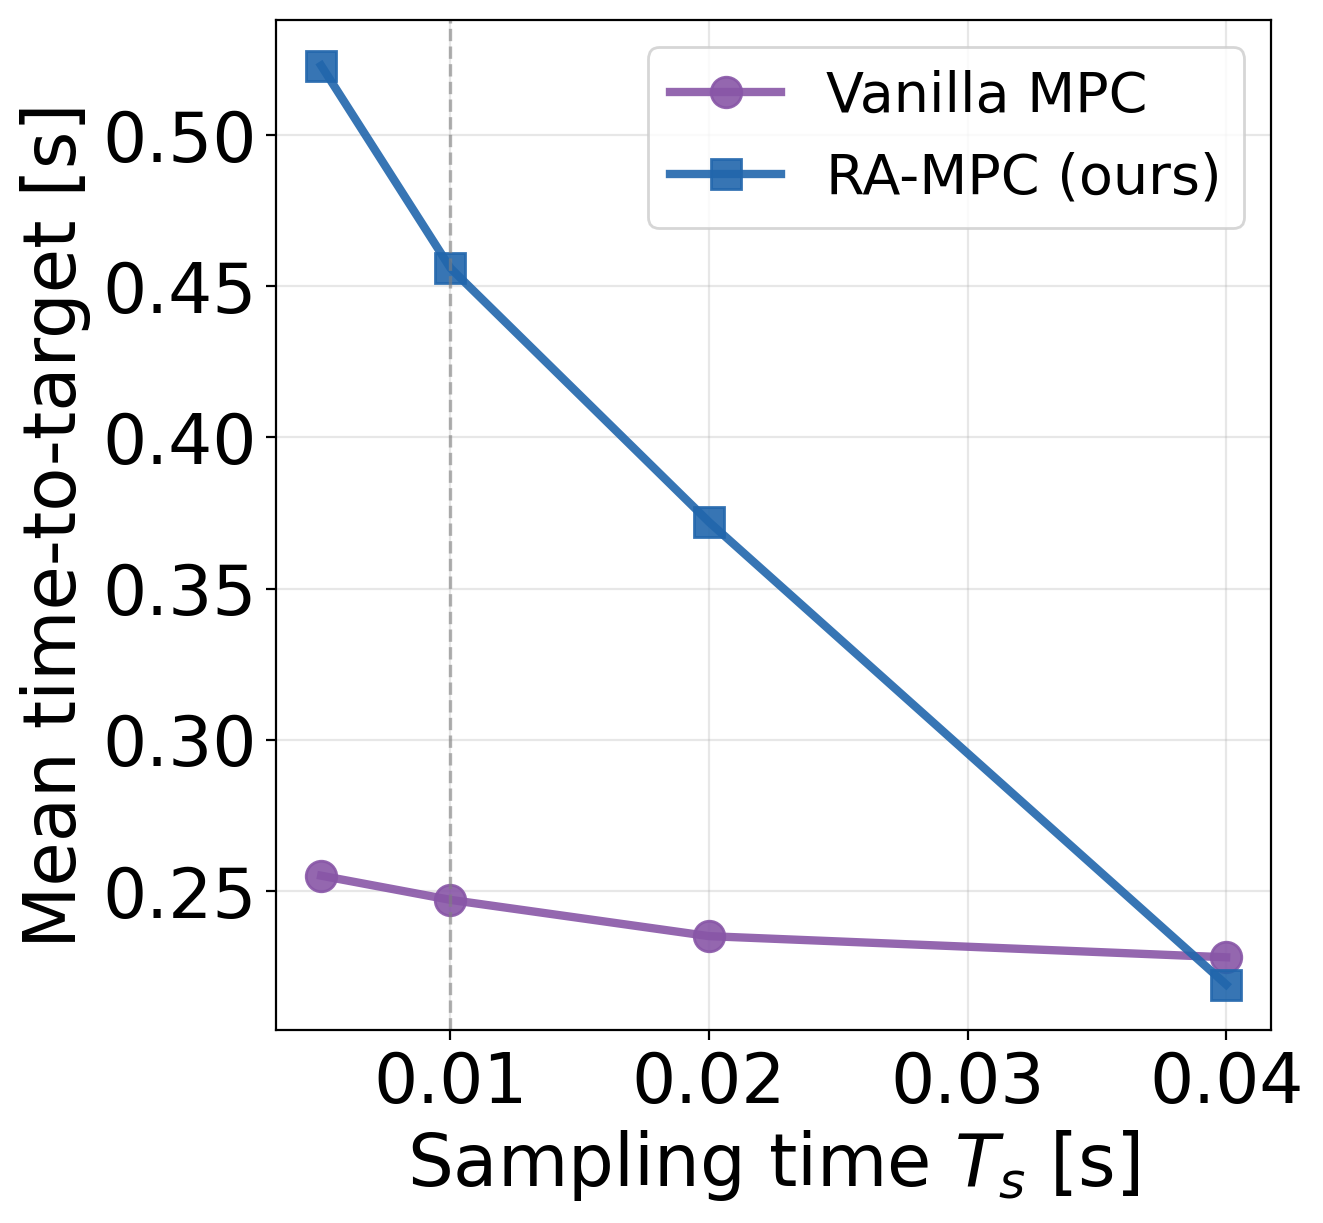

saved manipulator_sweep_time_to_target.png


In [ ]:
# ── Plot 2: mean time-to-target vs sampling time (successful trajectories) ────
px_fig = 1 / plt.rcParams["figure.dpi"]
fig, ax = plt.subplots(figsize=(650 * px_fig, 600 * px_fig), layout="constrained")
fig.set_dpi(200)
for m in methods:
    sub = summary[summary["method"] == m].sort_values("dt_mpc")
    ax.plot(
        sub["dt_mpc"],
        sub["mean_ttt"],
        color=col_c[m],
        marker=mk[m],
        lw=3,
        ms=11,
        alpha=0.9,
        label=m,
    )
ax.axvline(0.01, color="gray", lw=1.2, ls="--", alpha=0.6)
ax.set_xlabel("Sampling time $T_s$ [s]", fontsize=fs - 4)
ax.set_ylabel("Mean time-to-target [s]", fontsize=fs - 4)
ax.xaxis.set_tick_params(labelsize=25)
ax.yaxis.set_tick_params(labelsize=25)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=20)
fig.savefig(
    os.path.join(REV_DATA, "manipulator_sweep_time_to_target.png"),
    dpi=200,
    bbox_inches="tight",
)
plt.show()
print("saved manipulator_sweep_time_to_target.png")

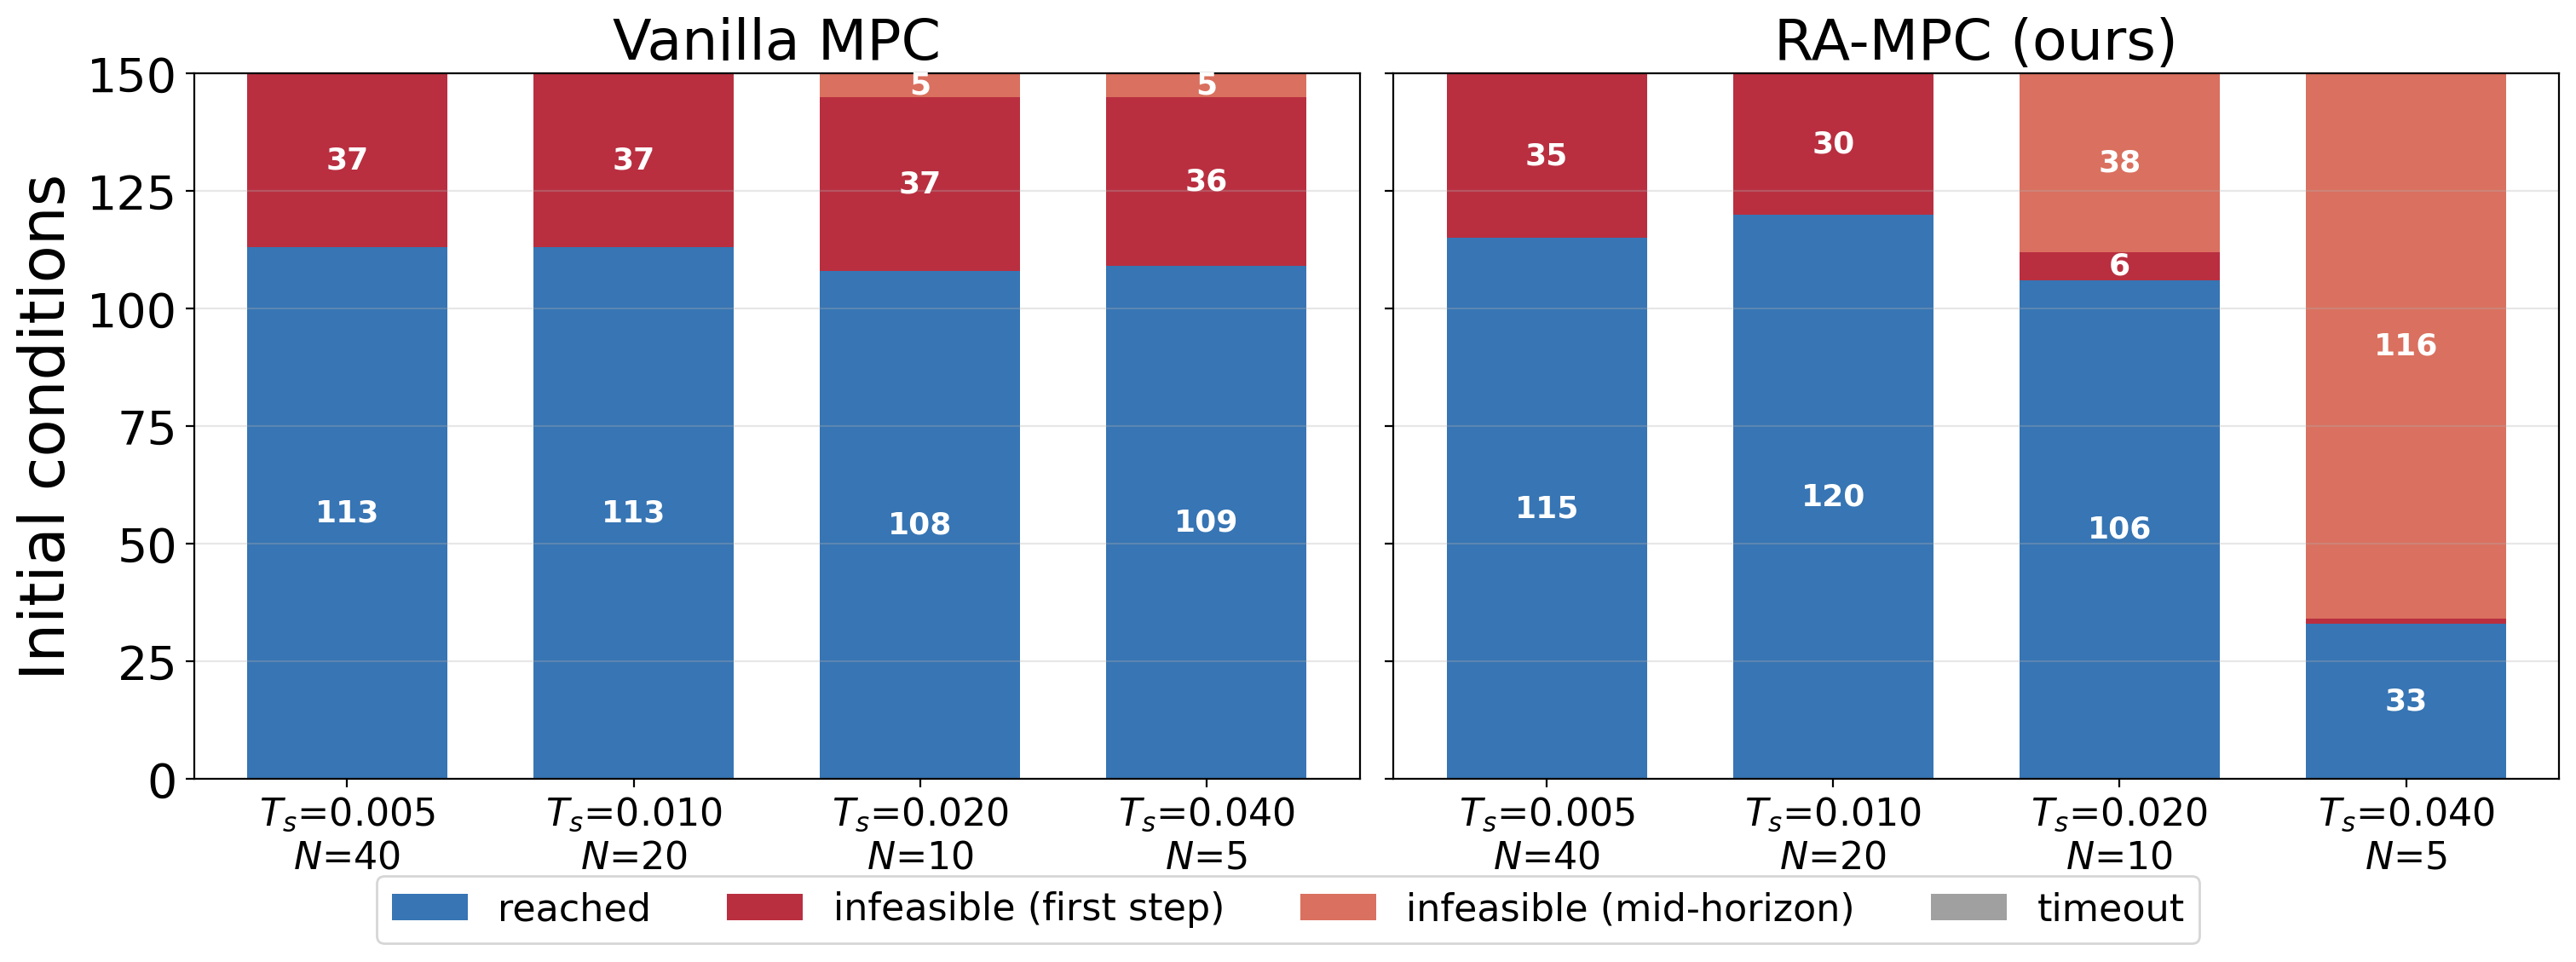

saved manipulator_sweep_outcomes.png


In [ ]:
# ── Plot 3: outcome breakdown (one stacked bar per method) ────────────────────
oc_cols = ["n_reached", "n_infeas_s1", "n_infeas_mid", "n_timeout"]
oc_lab = ["reached", "infeasible (first step)", "infeasible (mid-horizon)", "timeout"]
oc_clr = ["#2166ac", "#b2182b", "#d6604d", "#969696"]

px_fig = 1 / plt.rcParams["figure.dpi"]
fig, axes = plt.subplots(
    1, 2, figsize=(1500 * px_fig, 560 * px_fig), layout="constrained", sharey=True
)
fig.set_dpi(200)
for ax, m in zip(axes, methods):
    sub = summary[summary["method"] == m].sort_values("dt_mpc")
    xp = np.arange(len(sub))
    bottom = np.zeros(len(sub))
    for c, lbl, clr in zip(oc_cols, oc_lab, oc_clr):
        vals = sub[c].values.astype(float)
        ax.bar(xp, vals, bottom=bottom, label=lbl, color=clr, alpha=0.9, width=0.7)
        for xi, vi, bi in zip(xp, vals, bottom):
            if vi >= 3:
                ax.text(
                    xi,
                    bi + vi / 2,
                    f"{int(vi)}",
                    ha="center",
                    va="center",
                    fontsize=13,
                    color="white",
                    fontweight="bold",
                )
        bottom += vals
    ax.set_title(m, fontsize=fs - 6)
    ax.set_xticks(xp)
    ax.set_xticklabels(
        [f"$T_s$={c['dt_mpc']:.3f}\n$N$={c['N_hor']}" for c in CONFIGS], fontsize=16
    )
    ax.yaxis.set_tick_params(labelsize=20)
    ax.grid(axis="y", alpha=0.3)
axes[0].set_ylabel("Initial conditions", fontsize=fs - 4)
handles, labels_ = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_, fontsize=16, loc="outside lower center", ncol=4)
fig.savefig(
    os.path.join(REV_DATA, "manipulator_sweep_outcomes.png"),
    dpi=200,
    bbox_inches="tight",
)
plt.show()
print("saved manipulator_sweep_outcomes.png")